# Setup and Context

### Import Statements

In [74]:
import pandas as pd
import numpy as np
# required for visualisation
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

### Notebook Presentation

In [75]:
pd.options.display.float_format = '{:,.2f}'.format # setting display option

### Read the Data

In [76]:
df_data = pd.read_csv('nobel_prize_data.csv')

# basic data Exploration & Cleaning

* What is the shape of this dataset?
* What are the column names?
* In which year was the Nobel prize first awarded?
* Which year is the latest year included in the dataset?

In [77]:
df_data.shape

(962, 16)

In [78]:
df_data.columns

Index(['year', 'category', 'prize', 'motivation', 'prize_share',
       'laureate_type', 'full_name', 'birth_date', 'birth_city',
       'birth_country', 'birth_country_current', 'sex', 'organization_name',
       'organization_city', 'organization_country', 'ISO'],
      dtype='object')

In [79]:
df_data.head()

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Poland,Male,Marburg University,Marburg,Germany,POL
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Frédéric Passy,1822-05-20,Paris,France,France,Male,NaN,NaN,NaN,FRA
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Switzerland,Male,NaN,NaN,NaN,CHE


In [80]:
df_data.tail()

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
957,2020,Medicine,The Nobel Prize in Physiology or Medicine 2020,“for the discovery of Hepatitis C virus”,1/3,Individual,Michael Houghton,1949-07-02,NaN,United Kingdom,United Kingdom,Male,University of Alberta,Edmonton,Canada,GBR
958,2020,Peace,The Nobel Peace Prize 2020,"“for its efforts to combat hunger, for its con...",1/1,Organization,World Food Programme (WFP),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
959,2020,Physics,The Nobel Prize in Physics 2020,“for the discovery of a supermassive compact o...,1/4,Individual,Andrea Ghez,1965-06-16,"New York, NY",United States of America,United States of America,Female,University of California,"Berkeley, CA",United States of America,USA
960,2020,Physics,The Nobel Prize in Physics 2020,“for the discovery of a supermassive compact o...,1/4,Individual,Reinhard Genzel,1952-03-24,Bad Homburg vor der Höhe,Germany,Germany,Male,University of California,"Los Angeles, CA",United States of America,DEU
961,2020,Physics,The Nobel Prize in Physics 2020,“for the discovery that black hole formation i...,1/2,Individual,Roger Penrose,1931-08-08,Colchester,United Kingdom,United Kingdom,Male,University of Oxford,Oxford,United Kingdom,GBR


#### This dataset contains data from 1901 to 2020 nobel prize winner details with year, country, prize share etc. This dataset has total 962 entries with 16 feature.

* Are there any duplicate values in the dataset?
* Are there NaN values in the dataset?
* Which columns tend to have NaN values?
* How many NaN values are there per column?
* Why do these columns have NaN values?  

### Check for Duplicates

In [81]:
df_data.duplicated().any()

np.False_

#### There is no duplicated entry.

### Check for NaN Values

In [82]:
df_data.isna().sum()

,0
year,0
category,0
prize,0
motivation,88
prize_share,0
laureate_type,0
full_name,0
birth_date,28
birth_city,31
birth_country,28


#### The dataset contains several missing values, especially in organization_name and organization_country.

In [83]:
# replacing null organization name with unknown and organization country with unknown
df_data['organization_name'].fillna('Independent', inplace=True)
df_data['organization_country'].fillna('Unknown', inplace=True)
df_data['organization_city'].fillna('Unknown', inplace=True)

/tmp/ipykernel_701/3195052241.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_701/3195052241.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

### Type Conversions

* Converting the `birth_date` column to Pandas `Datetime` objects
* Adding a Column called `share_pct` which has the laureates' share as a percentage in the form of a floating-point number.

#### Convert Birth Date to Datetime

In [84]:
df_data.birth_date.dtype

dtype('O')

In [85]:
df_data['birth_date'] = pd.to_datetime(df_data['birth_date'])
df_data.birth_date.dtype

dtype('<M8[ns]')

#### Add a Column with the Prize Share as a Percentage

In [86]:
seperated_values = df_data.prize_share.str.split('/' , expand=True)
numerator = pd.to_numeric(seperated_values[0])
denominator = pd.to_numeric(seperated_values[1])
df_data['share_pct'] = (numerator/denominator)

# Plotly Donut Chart: Percentage of Male vs. Female Laureates

In [87]:
sex = df_data['sex'].value_counts() #count how many unique sex
fig = px.pie(labels = sex.index, values=sex.values, names=sex.index, hole=0.4)
fig.update_traces(textposition = 'outside',textinfo = 'percent+label')
fig.show()

#### There is only 6.21 % female recipients of nobel prize

# Who were the first 3 Women to Win the Nobel Prize?

* What are the names of the first 3 female Nobel laureates?
* What did the win the prize for?
* What do you see in their `birth_country`? Were they part of an organisation?

In [88]:
sorted_year = df_data.sort_values('year')
num_female = (sorted_year['sex'] == 'Female').sum()
print(f"Total number of female prize recipient {num_female}")

Total number of female prize recipient 58


In [89]:
sorted_year[sorted_year['sex'] == 'Female'][0:3] # check who are those female

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
18,1903,Physics,The Nobel Prize in Physics 1903,"""in recognition of the extraordinary services ...",1/4,Individual,"Marie Curie, née Sklodowska",1867-11-07,Warsaw,Russian Empire (Poland),Poland,Female,Independent,Unknown,Unknown,POL,0.25
29,1905,Peace,The Nobel Peace Prize 1905,NaN,1/1,Individual,"Baroness Bertha Sophie Felicita von Suttner, n...",1843-06-09,Prague,Austrian Empire (Czech Republic),Czech Republic,Female,Independent,Unknown,Unknown,CZE,1.00
51,1909,Literature,The Nobel Prize in Literature 1909,"""in appreciation of the lofty idealism, vivid ...",1/1,Individual,Selma Ottilia Lovisa Lagerlöf,1858-11-20,Mårbacka,Sweden,Sweden,Female,Independent,Unknown,Unknown,SWE,1.00


#### Till 2020 there are 58 total female recipient of nobel prize. First female winner was Marie Curie, née Sklodowska from poland. She was awarded the prize for physics. For first three female winner organization country is unknown.

## Find the Repeat Winners

In [90]:
repeat_prize = df_data.duplicated(subset=['full_name'], keep = False)
multiple_winner = df_data[repeat_prize]
multiple_winner.full_name

,full_name
18,"Marie Curie, née Sklodowska"
62,"Marie Curie, née Sklodowska"
89,Comité international de la Croix Rouge (Intern...
215,Comité international de la Croix Rouge (Intern...
278,Linus Carl Pauling
283,Office of the United Nations High Commissioner...
297,John Bardeen
306,Frederick Sanger
340,Linus Carl Pauling
348,Comité international de la Croix Rouge (Intern...


## Number of Prizes per Category
* How many unique categories are there?
* Which category has the most number of prizes awarded?
* Which category has the fewest number of prizes awarded?

In [91]:
categories = df_data.category.value_counts()

In [92]:
fig = px.bar(x = categories.index,
             y = categories.values,
             title = 'Category vs Count',
             color_continuous_scale = 'Aggrnyl',
             color = categories.index)
fig.update_layout(xaxis_title = 'Category', yaxis_title = 'number of Prize count')
fig.show()

#### There are six categories in which Nobel Prizes are awarded. Medicine and Physics have the most laureates, while Economics has the fewest.

* When was the first prize in the field of Peace awarded?
* Who did the prize go to?

In [93]:
sorted_year[sorted_year['category'] == 'Peace'][0:1]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Switzerland,Male,Independent,Unknown,Unknown,CHE,0.50


#### Jean Henry Dunant was the forst recipient of peace prize in 1901.

* How there is gender distribution across categories?

In [94]:
category_sex = df_data.groupby(['category','sex'], as_index=False).agg({'prize':pd.Series.count})
category_sex

,category,sex,prize
0,Chemistry,Female,7
1,Chemistry,Male,179
2,Economics,Female,2
3,Economics,Male,84
4,Literature,Female,16
5,Literature,Male,101
6,Medicine,Female,12
7,Medicine,Male,210
8,Peace,Female,17
9,Peace,Male,90


In [95]:
fig = px.bar(category_sex, x = 'category',
             y = 'prize',
             title = 'Number of Prizes Awarded per Category split by Men and Women',
             color = 'sex')
fig.update_layout(xaxis_title = 'Nobel Prize Category', yaxis_title = 'number of Prize')

fig.show()

#### Number of female representatives are way too less than male for each category.

* How the distribution of prize varies across the years?

In [96]:
prize_per_year = df_data.groupby(by='year').count().prize
prize_per_five_year = prize_per_year.rolling(window=5).mean() # 5 year rolling mean

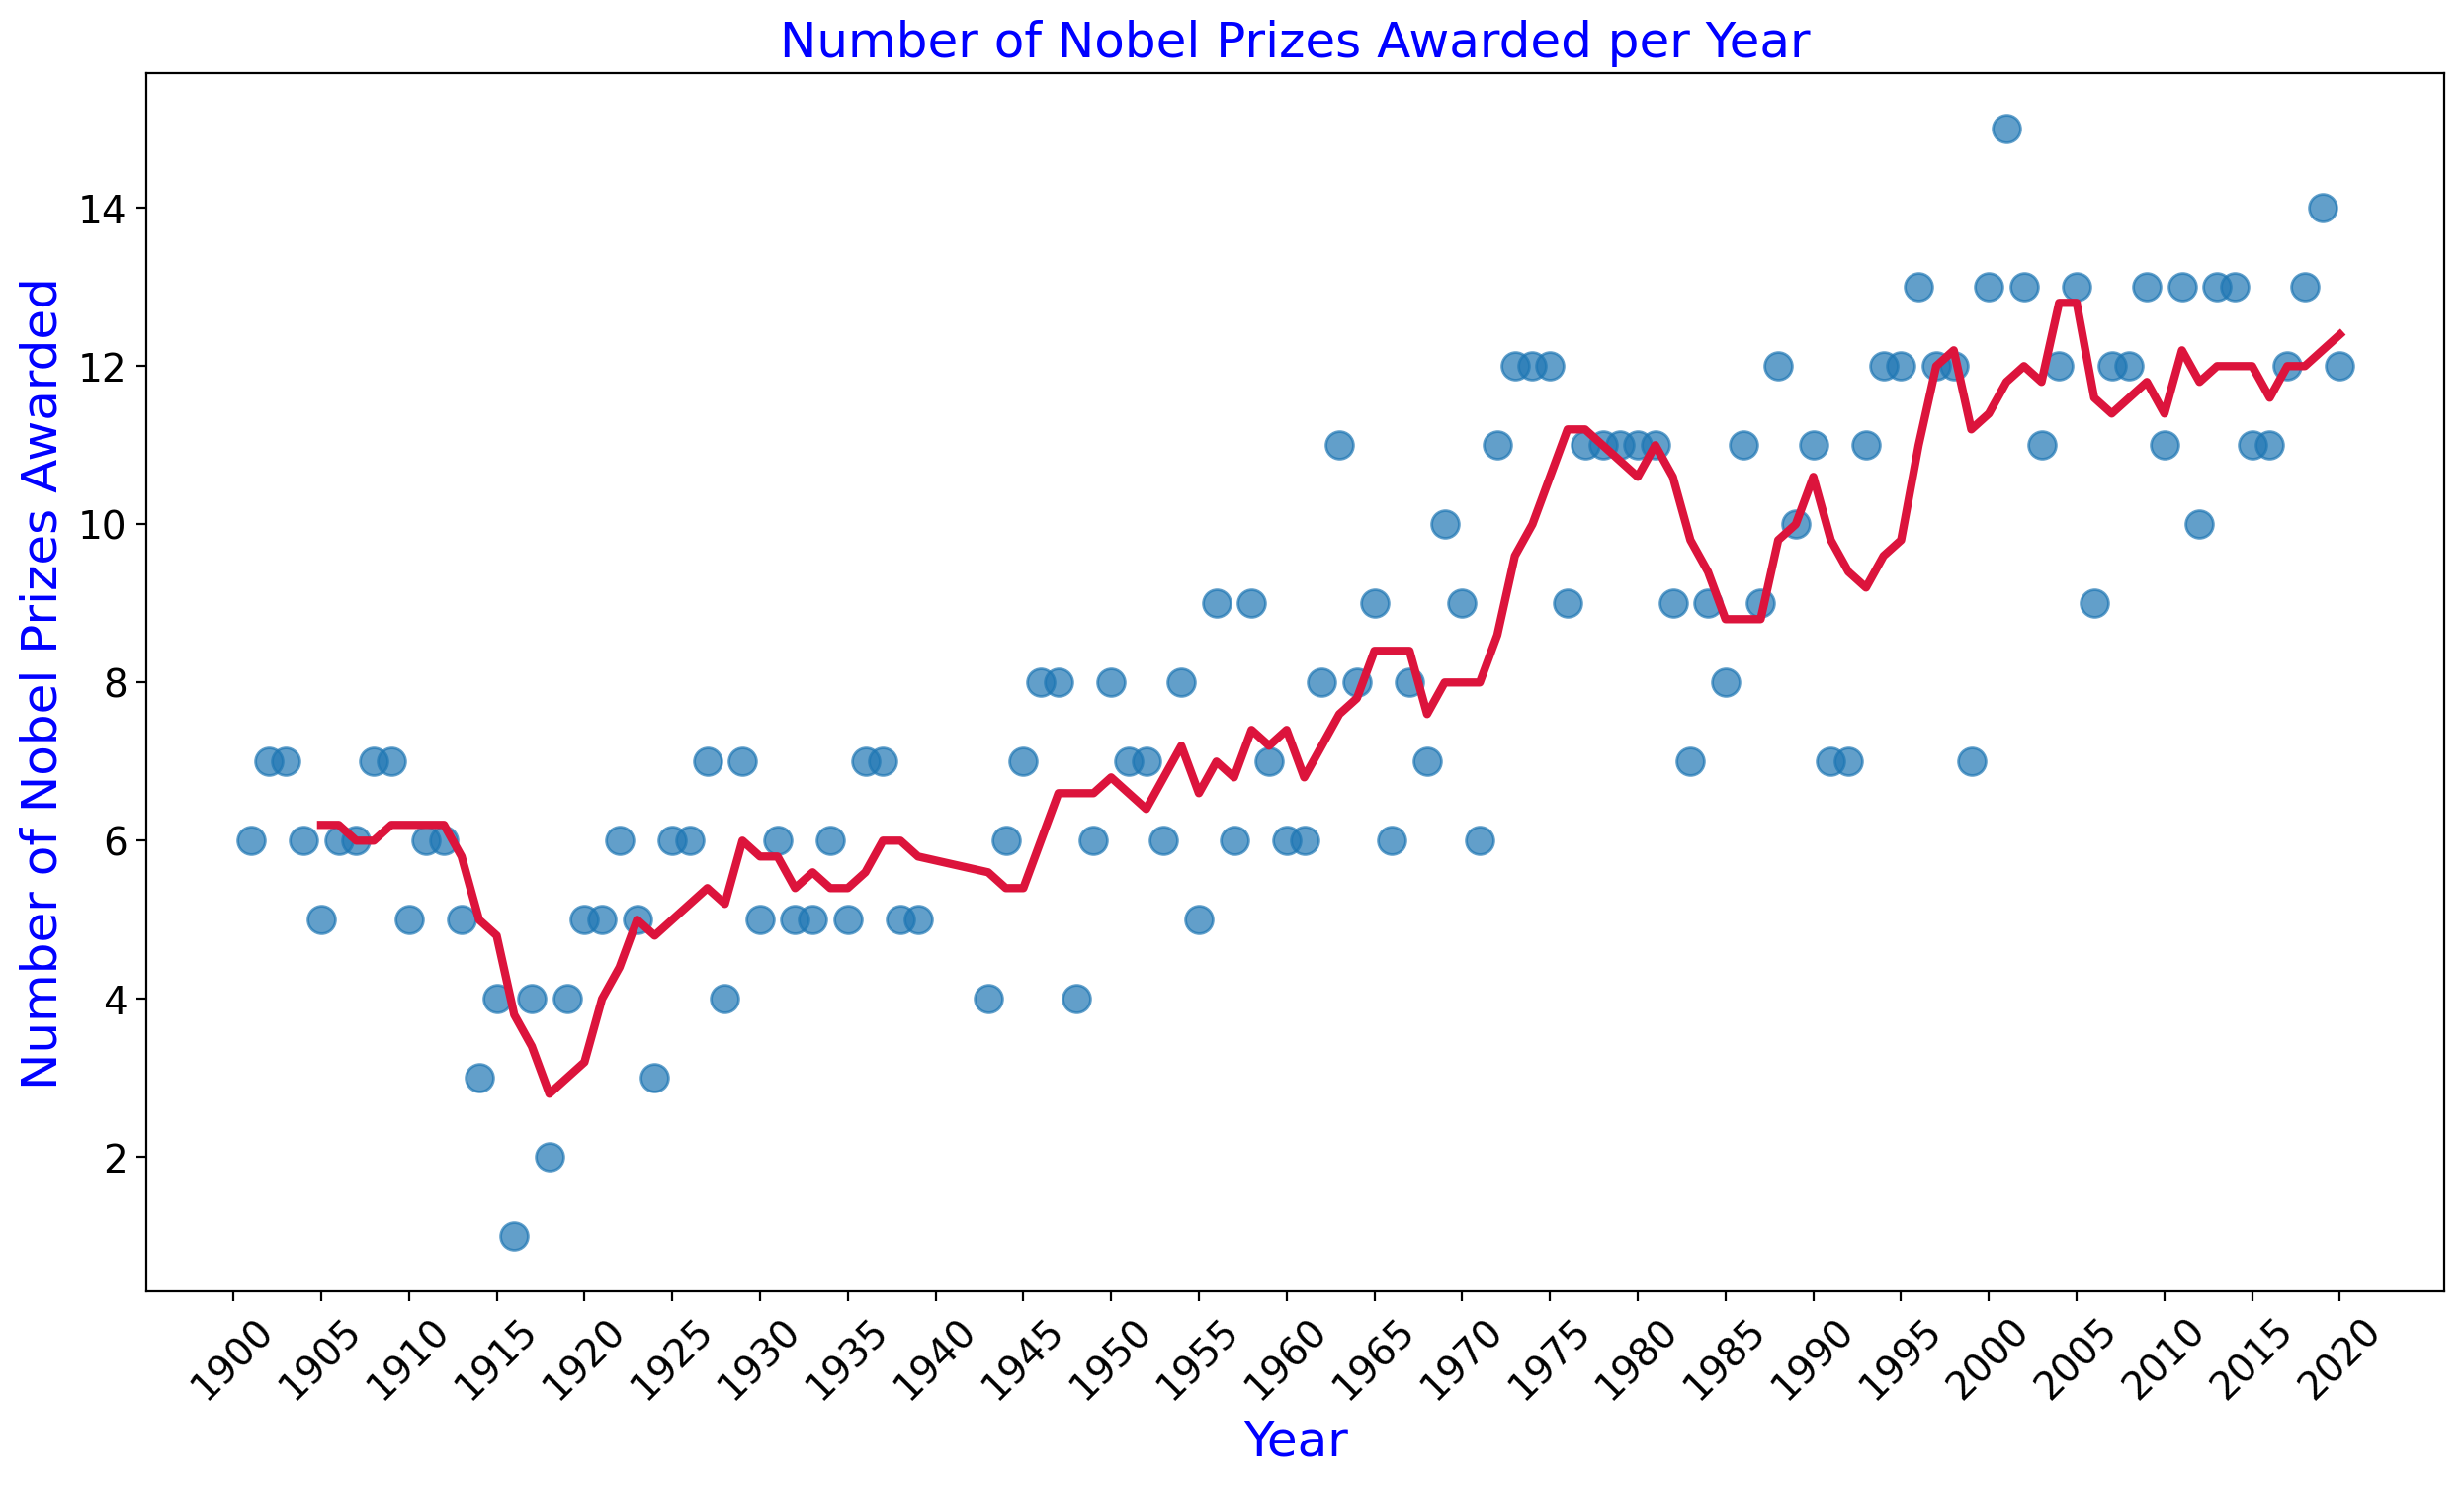

In [97]:
plt.figure(figsize=(15,8), dpi=200)
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18, color = 'blue')
plt.xlabel('Year', fontsize=18, color = 'blue')
plt.ylabel('Number of Nobel Prizes Awarded', fontsize=18, color = 'blue')
plt.xticks(np.arange(1900,2021,5),fontsize=14 , rotation=45)
plt.yticks(fontsize=14)
plt.scatter(x = prize_per_year.index,  y = prize_per_year.values, alpha=0.7, s = 100 )
plt.plot(prize_per_year.index, prize_per_five_year.values , c = 'crimson', linewidth=3)

#### There is overall upward trend across years.

* Calculate the average prize share of the winners on a year by year basis.
* Calculate the 5 year rolling average of the percentage share.

In [98]:
share_per_year = df_data.groupby(by='year').agg({'share_pct':pd.Series.mean})
share_per_five_year = share_per_year.rolling(window=5).mean()

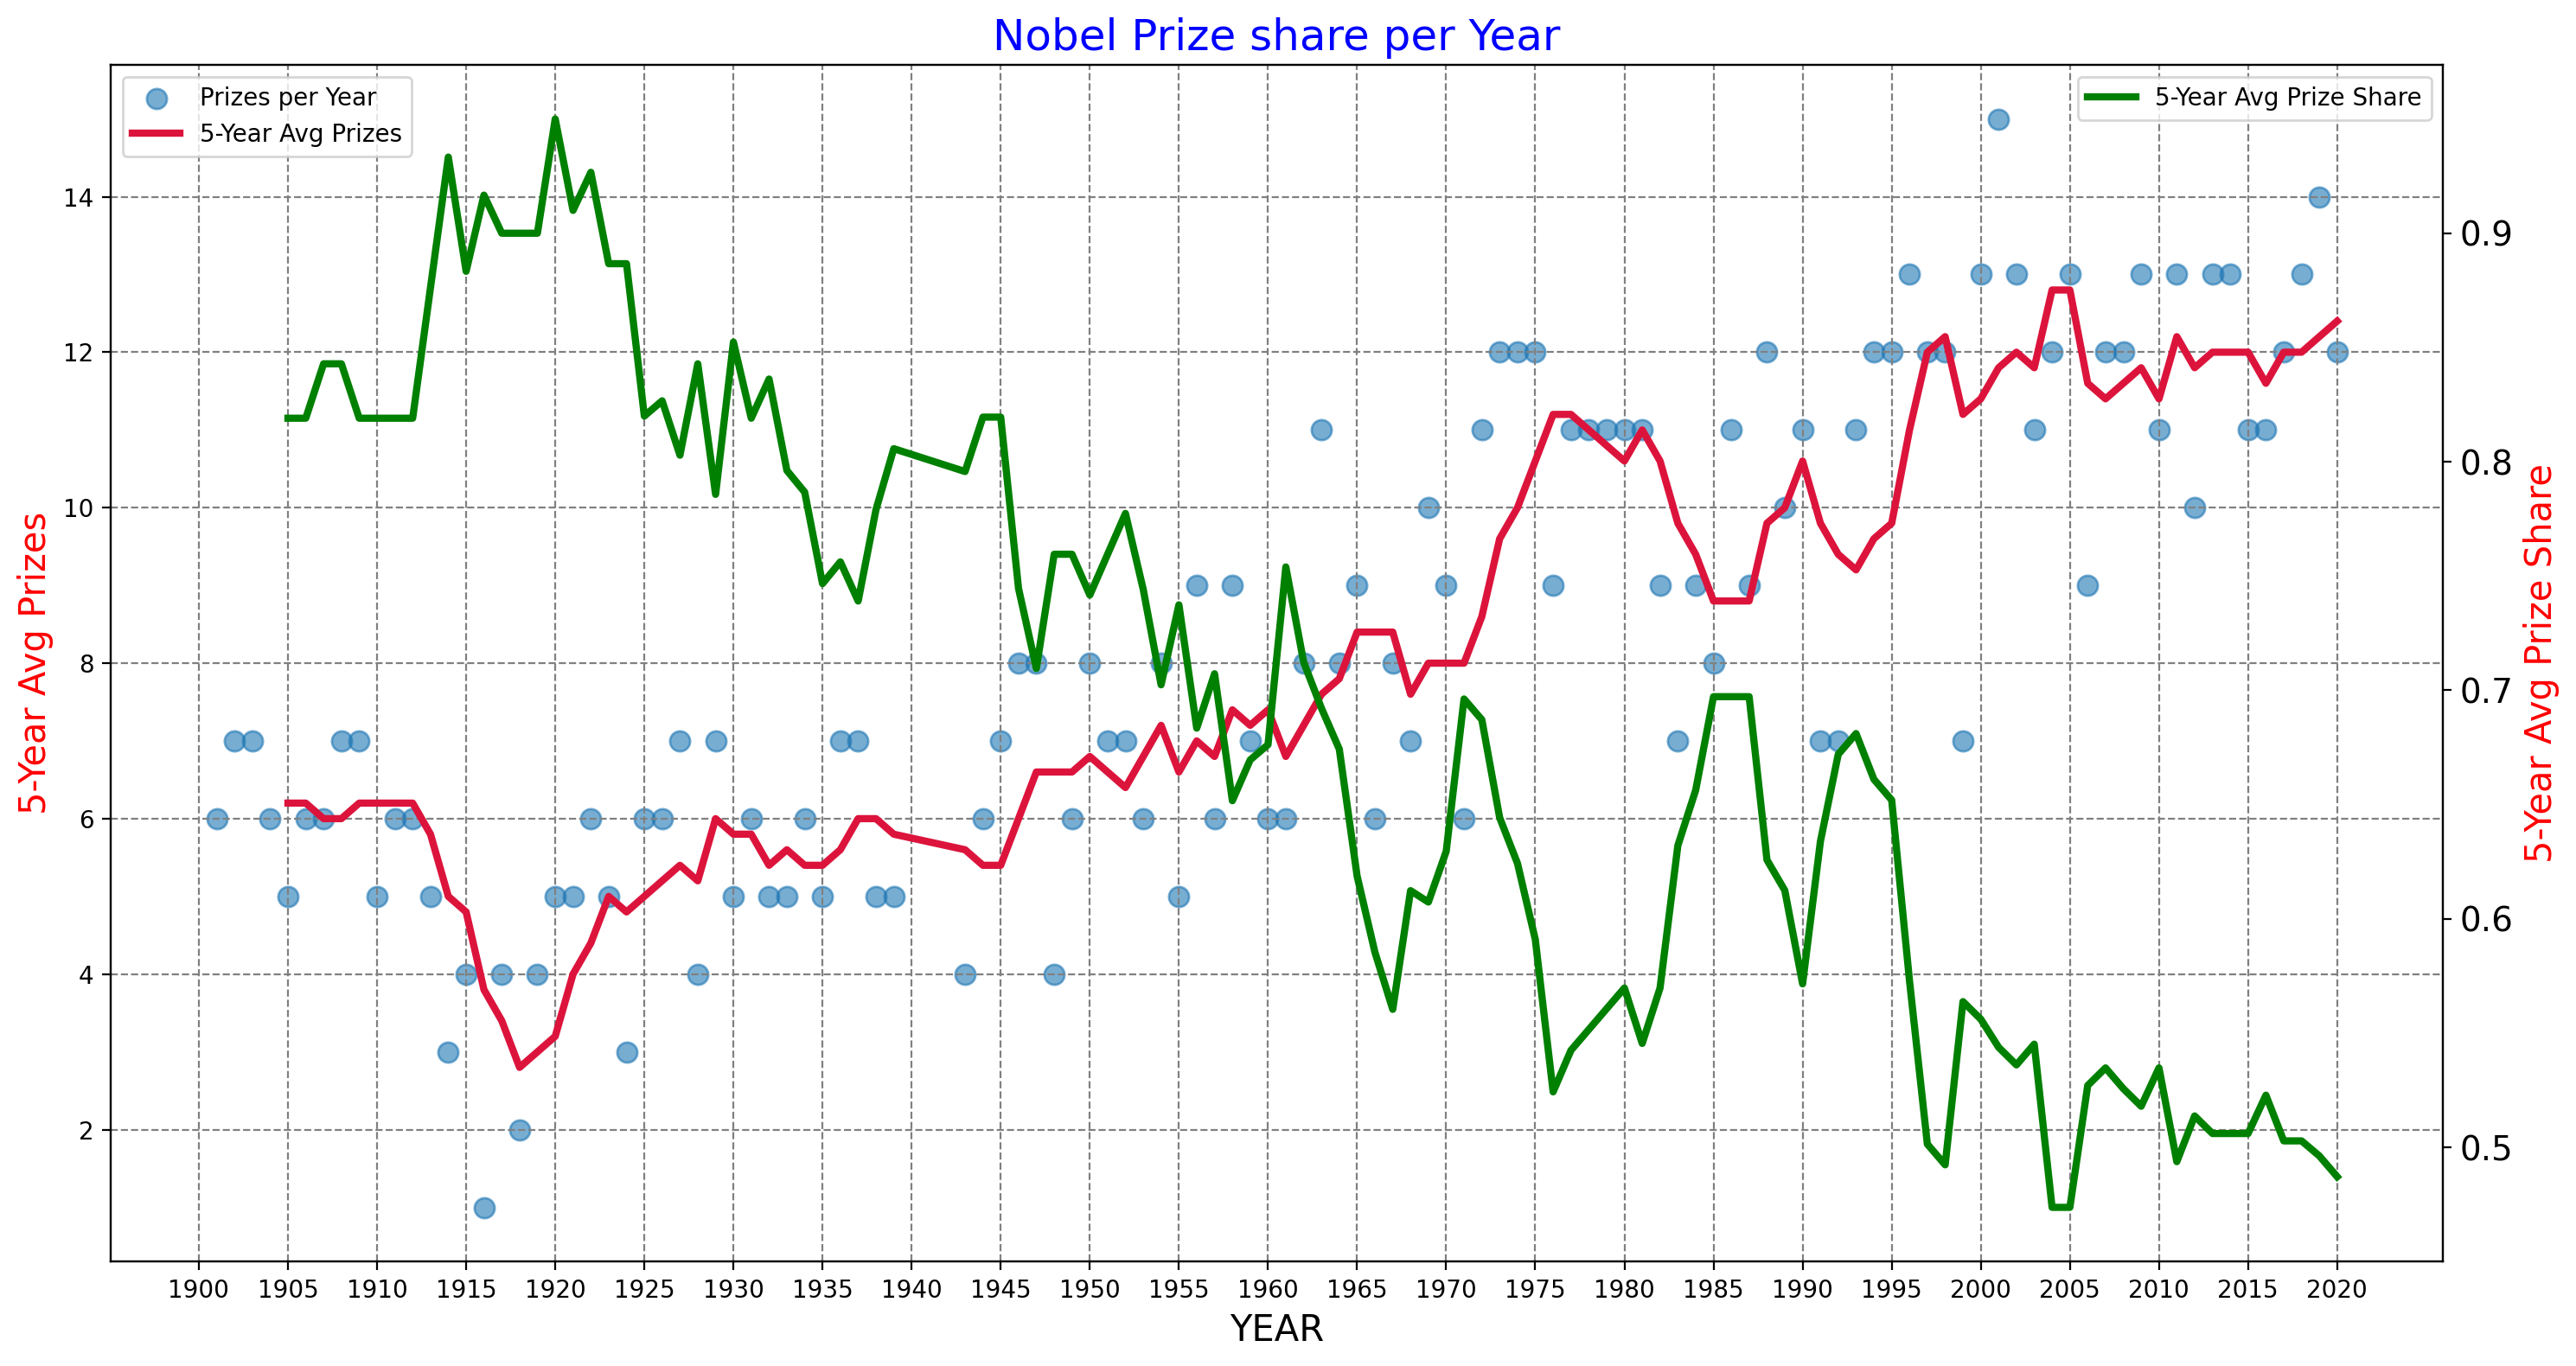

In [99]:
fig , ax1 = plt.subplots(figsize=(15,8), dpi=200)
ax2 = ax1.twinx()

plt.title('Nobel Prize share per Year', fontsize=18, color = 'blue')
plt.xticks(np.arange(1900,2021,5),fontsize=14 , rotation=45)
plt.xticks(rotation=45)
plt.yticks(fontsize=14)

ax1.grid(color='grey', linestyle='--')
ax1.set_xlabel('YEAR', fontsize=15)
ax1.set_ylabel('5-Year Avg Prizes', color = 'red', fontsize=15)
ax2.set_ylabel('5-Year Avg Prize Share',color = 'red', fontsize=15)

ax1.scatter(x = prize_per_year.index,  y = prize_per_year.values, alpha=0.6, s = 70, label='Prizes per Year') #number of prizes awarded each year
ax1.plot(prize_per_year.index, prize_per_five_year.values , c = 'crimson', linewidth=3, label='5-Year Avg Prizes') #smoothed trend of prize counts
ax2.plot(prize_per_year.index, share_per_five_year.values , c='green', linewidth=3, label='5-Year Avg Prize Share') #trend of prize sharing among laureates

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### The plot shows that the average number of prizes awarded is increasing, while the average prize share among laureates is decreasing.

## Top 20 Countries with the Most Nobel Prizes

In [100]:
top_20_countries = df_data.groupby(['birth_country_current'], as_index=False).agg({'prize':pd.Series.count})
top_20_countries.sort_values(by='prize', inplace = True)
top_countries = top_20_countries[-20:]
top_20_countries.columns

Index(['birth_country_current', 'prize'], dtype='object')

In [101]:
h_bar = px.bar(y = top_countries.birth_country_current,
               x = top_countries.prize,
               orientation = 'h',
               title='Top 20 countries in prize distribution',
               color_continuous_scale='Viridis',
               color=top_countries.prize)

h_bar.update_layout(xaxis_title='Number of Prize', yaxis_title='birth_country',coloraxis_showscale=False )
h_bar.show()

* How are Nobel Prize winners distributed worldwide by birth country?

In [102]:
df_countries = df_data.groupby(['birth_country_current','ISO'],as_index=False).agg({'prize':pd.Series.count})
df_countries.sort_values('prize',ascending=False)

,birth_country_current,ISO,prize
74,United States of America,USA,281
73,United Kingdom,GBR,105
26,Germany,DEU,84
25,France,FRA,57
67,Sweden,SWE,29
...,...,...,...
63,Slovakia,SVK,1
75,Venezuela,VEN,1
76,Vietnam,VNM,1
77,Yemen,YEM,1


In [103]:
world_map = px.choropleth(df_countries, locations='ISO',hover_name='birth_country_current', color='prize',
                          color_continuous_scale=px.colors.sequential.matter)
world_map.update_layout(coloraxis_showscale = True)
world_map.show()

#### USA have the maximum number of winners followed by UK.

* How many Nobel Prize winners are there by birth country and category?

In [104]:
cat_country = df_data.groupby(['birth_country_current', 'category'],
                               as_index=False).agg({'prize': pd.Series.count})
cat_country.sort_values(by='prize', ascending=False, inplace=True)

In [105]:
merged_df = pd.merge(cat_country, top_countries, on='birth_country_current')
merged_df.columns = ['birth_country_current', 'category', 'cat_prize', 'total_prize']
merged_df.sort_values(by='total_prize', inplace=True)
merged_df.columns

Index(['birth_country_current', 'category', 'cat_prize', 'total_prize'], dtype='object')

In [106]:
h1_bar = px.bar(y = merged_df.birth_country_current,
               x = merged_df.cat_prize,
               orientation = 'h',
               title='Top 20 countries divided in categories',
               color_continuous_scale='Viridis',
               color=merged_df.category)

h1_bar.update_layout(xaxis_title='Number of Prize', yaxis_title='birth_country',coloraxis_showscale=True )
h1_bar.show()

* How many Nobel Prize winners are there by birth country and year?

In [107]:
prize_by_year = df_data.groupby(by=['birth_country_current', 'year'], as_index=False).count()
prize_by_year = prize_by_year.sort_values('year')[['year', 'birth_country_current', 'prize']]

In [108]:
cumulative_prizes = prize_by_year.groupby(by=['birth_country_current',
                                              'year']).sum().groupby(level=[0]).cumsum()
cumulative_prizes.reset_index(inplace=True)
cumulative_prizes.sort_values(by=['birth_country_current', 'year'], inplace=True)


In [109]:
l_chart = px.line(
    cumulative_prizes,
    x='year',
    y='prize',
    color='birth_country_current',
    hover_name='birth_country_current'
)

l_chart.update_layout(
    xaxis_title='Year',
    yaxis_title='Number of Prizes'
)

l_chart.show()

#### The majority of Nobel laureates were born in the USA, the UK, France, and Germany.

* Which are the top 20 prize winner organization?

In [110]:
top_organization = df_data['organization_name'].value_counts()[:20]
top_organization.sort_values(ascending=True, inplace=True)

In [111]:
h1_bar = px.bar(y = top_organization.index, x =top_organization.values,
               orientation = 'h',
               title='Top 20 organization name',
               color_continuous_scale='Viridis',
               color = top_organization.values)

h1_bar.update_layout(xaxis_title='Number of Prize', yaxis_title='Institution', coloraxis_showscale=True )
h1_bar.show()

#### Most of the laureates have won the prize not as a part of any organization but independently. But the top organizations are University of California, Harvard University, Stanford university MIT etc.

* Where do major discoveries take place?  
* Where is the number one hotspot for discoveries in the world?
* Which city in Europe has had the most discoveries?

In [112]:
top_city = df_data['organization_city'].value_counts()[:20]
top_city.sort_values(ascending=True, inplace=True)

In [113]:
h1_bar = px.bar(y = top_city.index, x =top_city.values,
               orientation = 'h',
               title='Top 20 organization city ',
               color_continuous_scale=px.colors.sequential.Plasma,
               color = top_city.values)

h1_bar.update_layout(xaxis_title='Number of Prize', yaxis_title='Cities',coloraxis_showscale=True)
h1_bar.show()

#### Cambridge MA, USA is the top organization which alone has around 50 nobel laureates. New york, Cambridge, London Paris are also on the top of the list.

## Where are Nobel Laureates Born?
* What percentage of the United States prizes came from Nobel laureates born in New York?
* How many Nobel laureates were born in London, Paris and Vienna?
* Out of the top 5 cities, how many are in the United States?


In [114]:
top_birth_city = df_data['birth_city'].value_counts()[:20]
top_birth_city.sort_values(ascending=True, inplace=True)

In [115]:
h1_bar = px.bar(y = top_birth_city.index, x = top_birth_city.values,
               orientation = 'h',
               title='Top 20 birth city of winners',
               color_continuous_scale=px.colors.sequential.Plasma,
               color = top_birth_city.values)

h1_bar.update_layout(xaxis_title='Number of Prize', yaxis_title='Birth City',coloraxis_showscale=True)
h1_bar.show()

#### Over 50 Nobel Prize winners were born in New York. Paris and London also have more than 20 laureates each.

* How many Nobel Prizes are associated with each organization country, organization city, and organization name?

In [116]:
prizes_per_organisation = df_data.groupby(['organization_country','organization_city','organization_name'],as_index=False).agg({'prize':pd.Series.count})
prizes_per_organisation = prizes_per_organisation[:20]


In [117]:
fig = px.sunburst(prizes_per_organisation,
                  path=['organization_country','organization_city', 'organization_name'],
                  values='prize',
                  title='Where do Discoveries Take Place?',
                   )

fig.update_layout(xaxis_title='Number of Prizes',
                    yaxis_title='City',
                    coloraxis_showscale=False)
fig.show()

#### The top cities with the most Nobel-winning organizations are Austria, Canada, Belgium, and Australia.

## Patterns in the Laureate Age at the Time of the Award

* How Old Are the Laureates When the Win the Prize?





In [118]:
birth_year = df_data['birth_date'].dt.year

In [119]:
df_data['winning age'] = df_data['year'] - birth_year

### Who were the oldest and youngest winners?


In [120]:
sorted_age = df_data.sort_values('winning age')
sorted_age['winning age'].min()


17.0

In [121]:
sorted_age[sorted_age['winning age'] == 17]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct,winning age
885,2014,Peace,The Nobel Peace Prize 2014,"""for their struggle against the suppression of...",1/2,Individual,Malala Yousafzai,1997-07-12,Mingora,Pakistan,Pakistan,Female,Independent,Unknown,Unknown,PAK,0.50,17.00


In [122]:
sorted_age = df_data.sort_values('winning age')
sorted_age['winning age'].max()


97.0

In [123]:
sorted_age[sorted_age['winning age'] == 97]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct,winning age
937,2019,Chemistry,The Nobel Prize in Chemistry 2019,“for the development of lithium-ion batteries”,1/3,Individual,John Goodenough,1922-07-25,Jena,Germany,Germany,Male,University of Texas,Austin TX,United States of America,DEU,0.33,97.00


In [124]:
sorted_age.describe()

,year,birth_date,share_pct,winning age
count,962.00,934,962.00,934.00
mean,"1,971.82",1912-03-28 22:50:37.259100416,0.63,59.95
min,"1,901.00",1817-11-30 00:00:00,0.25,17.00
25%,"1,948.00",1892-04-06 00:00:00,0.33,51.00
50%,"1,977.00",1917-10-30 12:00:00,0.50,60.00
75%,"2,001.00",1937-04-24 18:00:00,1.00,69.00
max,"2,020.00",1997-07-12 00:00:00,1.00,97.00
std,33.81,NaN,0.29,12.62


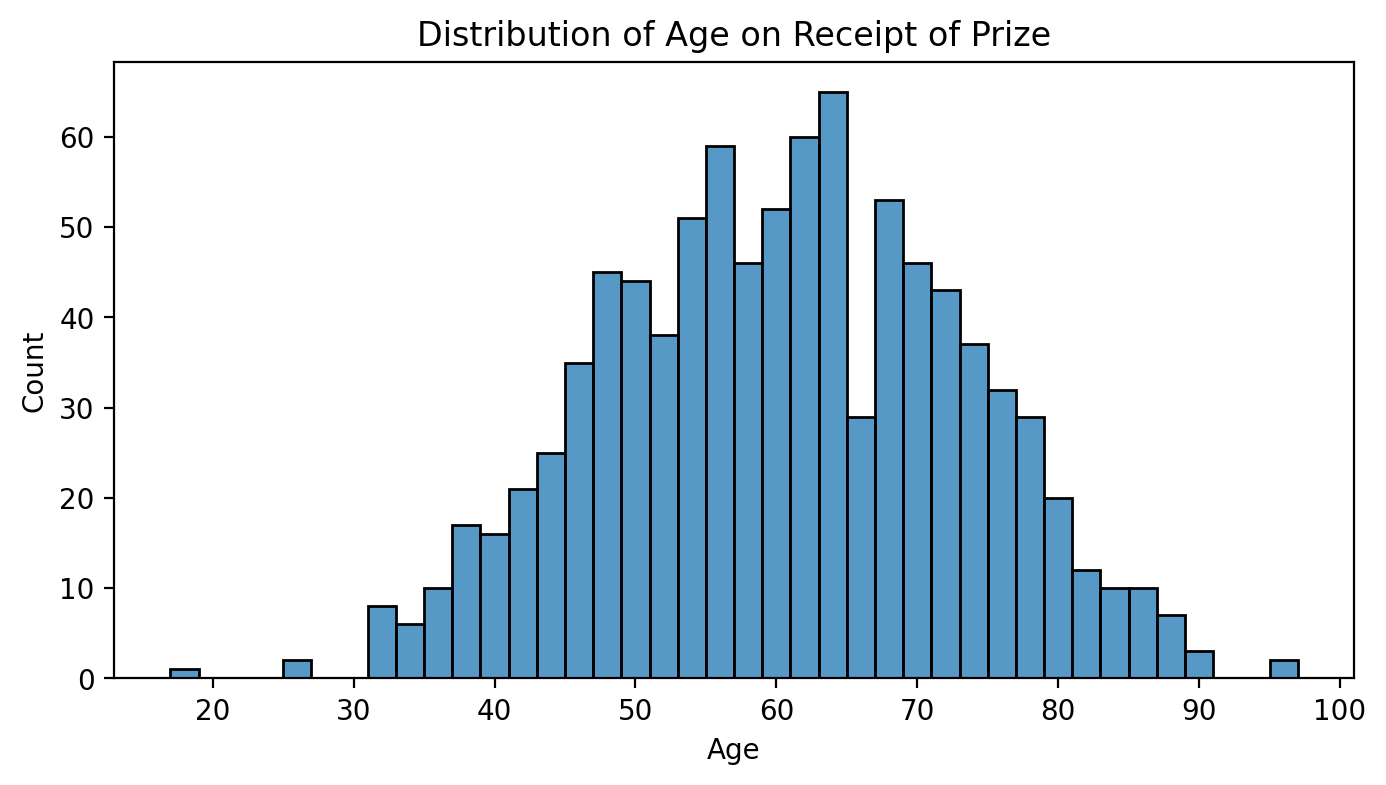

In [125]:
plt.figure(figsize=(8, 4), dpi=200)
sns.histplot(data=df_data,
             x='winning age',
             bins=40)
plt.xlabel('Age')
plt.title('Distribution of Age on Receipt of Prize')
plt.show()

#### Malala Yousafzai is the youngest Nobel Prize winner, awarded in the Peace category, while John B. Goodenough is the oldest winner, receiving the prize in Chemistry. Overall, most laureates are between 50 and 70 years of age.

* who are the winners from India?

In [126]:
df_data[df_data['birth_country'] == 'India']

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct,winning age
8,1902,Medicine,The Nobel Prize in Physiology or Medicine 1902,"""for his work on malaria, by which he has show...",1/1,Individual,Ronald Ross,1857-05-13,Almora,India,India,Male,University College London,Liverpool,United Kingdom,IND,1.00,45.00
75,1913,Literature,The Nobel Prize in Literature 1913,"""because of his profoundly sensitive, fresh an...",1/1,Individual,Rabindranath Tagore,1861-05-07,Calcutta,India,India,Male,Independent,Unknown,Unknown,IND,1.00,52.00
155,1930,Physics,The Nobel Prize in Physics 1930,"""for his work on the scattering of light and f...",1/1,Individual,Sir Chandrasekhara Venkata Raman,1888-11-07,Tiruchirappalli,India,India,Male,Calcutta University,Calcutta,India,IND,1.00,42.00
386,1968,Medicine,The Nobel Prize in Physiology or Medicine 1968,"""for their interpretation of the genetic code ...",1/3,Individual,Har Gobind Khorana,1922-01-09,Raipur,India,India,Male,University of Wisconsin,"Madison, WI",United States of America,IND,0.33,46.00
689,1998,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for his contributions to welfare economics""",1/1,Individual,Amartya Sen,1933-11-03,Santiniketan,India,India,Male,University of Cambridge,Cambridge,United Kingdom,IND,1.00,65.00
818,2009,Chemistry,The Nobel Prize in Chemistry 2009,"""for studies of the structure and function of ...",1/3,Individual,Venkatraman Ramakrishnan,1952-07-02,"Chidambaram, Tamil Nadu",India,India,Male,MRC Laboratory of Molecular Biology,Cambridge,United Kingdom,IND,0.33,57.00
884,2014,Peace,The Nobel Peace Prize 2014,"""for their struggle against the suppression of...",1/2,Individual,Kailash Satyarthi,1954-01-11,Vidisha,India,India,Male,Independent,Unknown,Unknown,IND,0.50,60.00
939,2019,Economics,The Sveriges Riksbank Prize in Economic Scienc...,“for their experimental approach to alleviatin...,1/3,Individual,Abhijit Banerjee,1961-02-21,Mumbai,India,India,Male,Massachusetts Institute of Technology (MIT),"Cambridge, MA",United States of America,IND,0.33,58.00


In [129]:
df_data[df_data['birth_country'] == 'India'].prize.count()

np.int64(8)

#### There are total 8 winners from india.

### Age at Time of Award throughout History

Are Nobel laureates being nominated later in life than before? Have the ages of laureates at the time of the award increased or decreased over time?




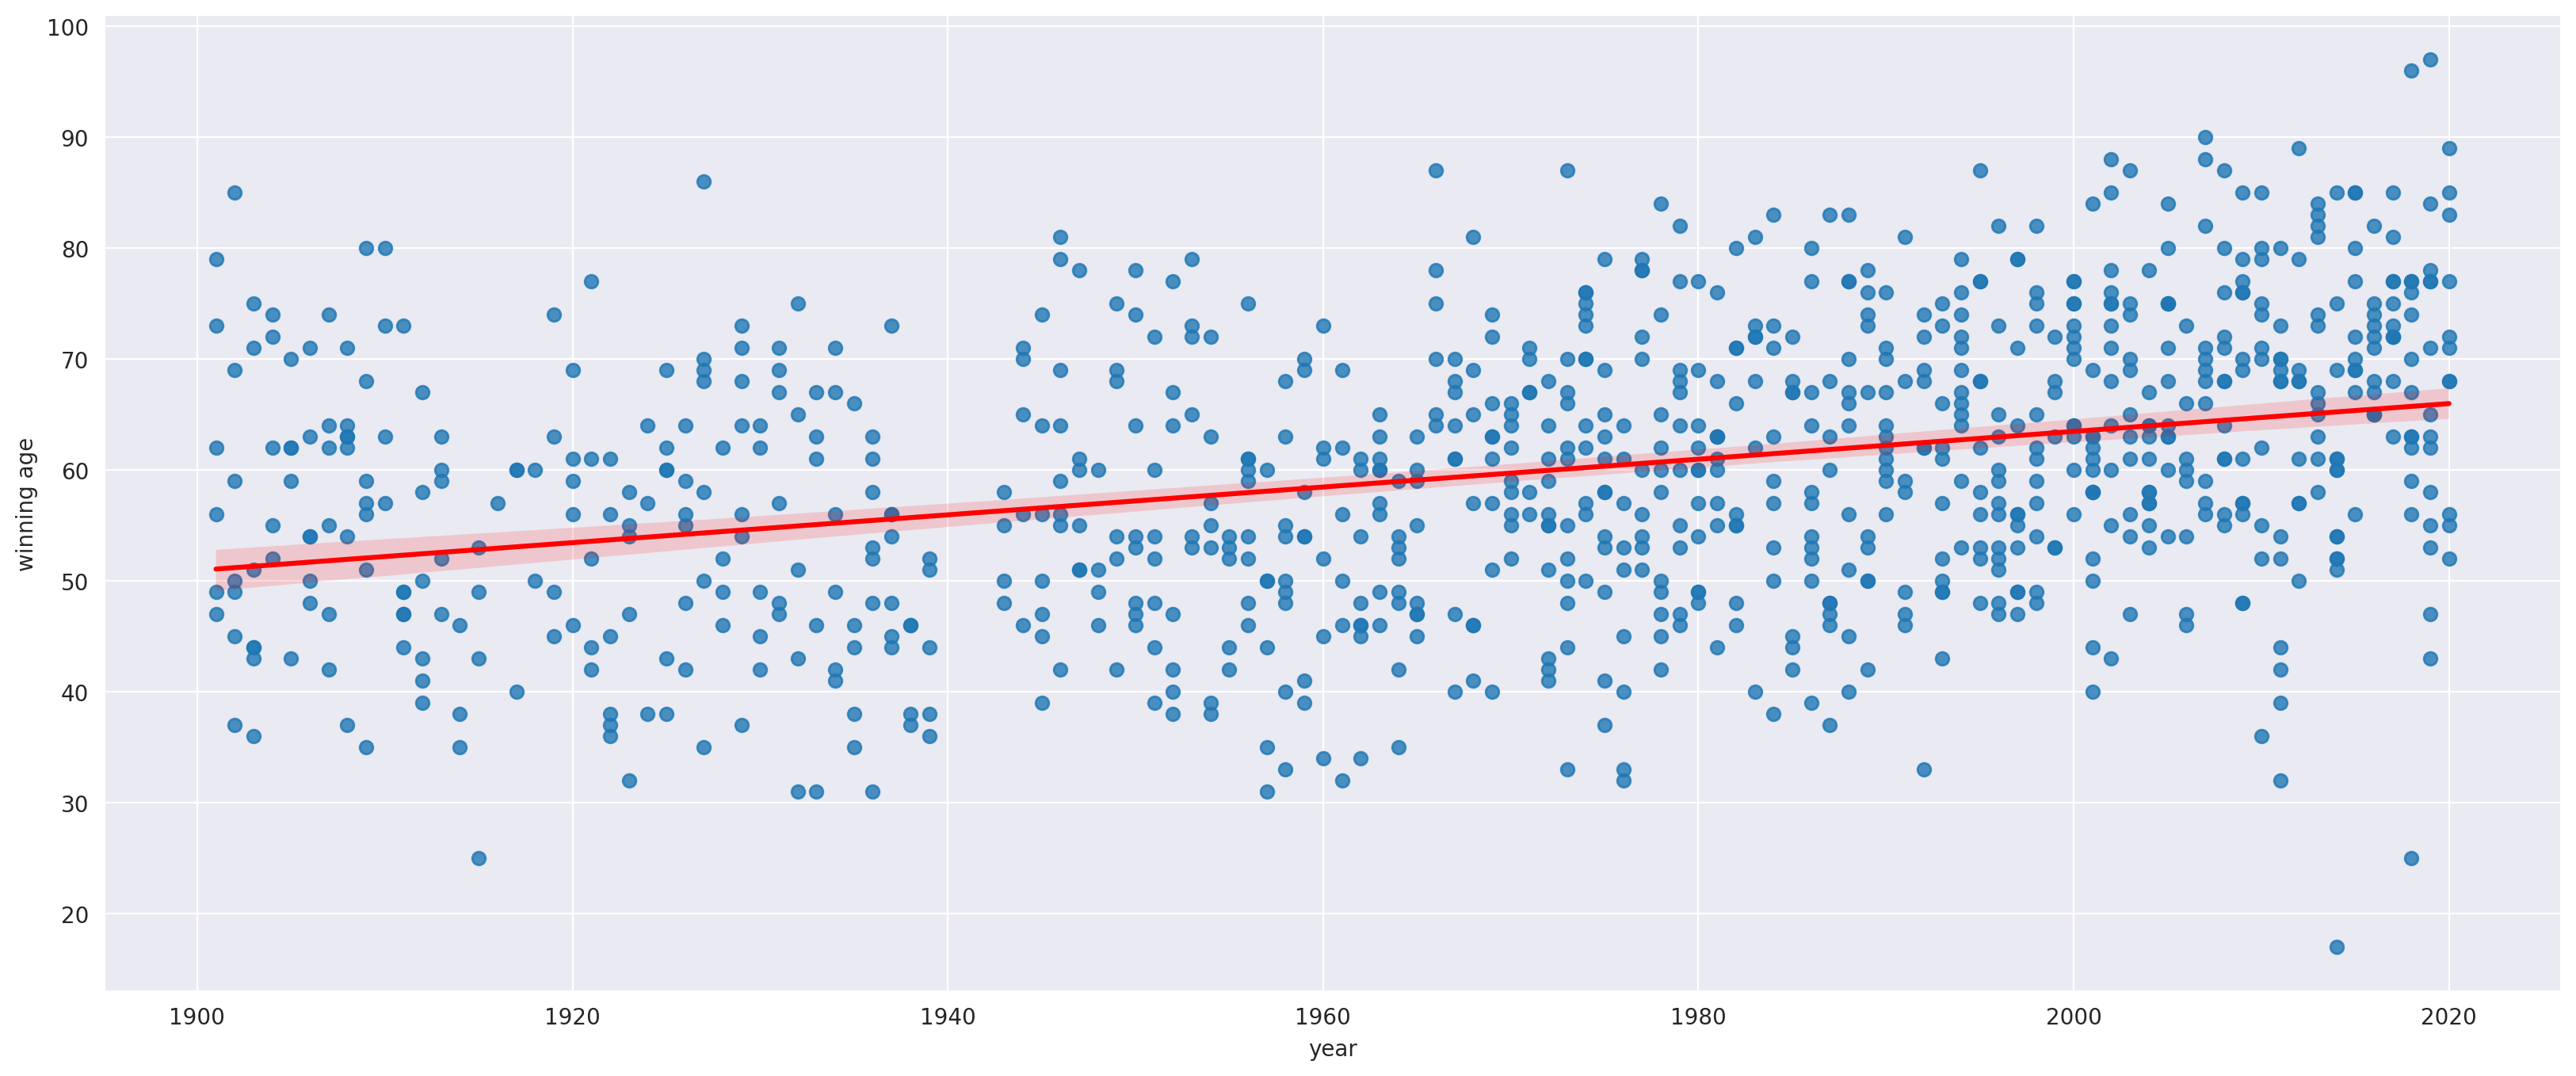

In [130]:
plt.figure(figsize=(20,8),dpi=200)
with sns.axes_style('darkgrid'):
  sns.regplot(df_data,
              x='year',
              y='winning age',
              scatter_kws = {'alpha':0.8},
              line_kws = {'color':'red'})

plt.show()

#### Over the years winning age has been increased.

### Winning Age Across the Nobel Prize Categories

* How does the age of laureates vary by category?

* In which prize category are the average winners the oldest?
* In which prize category are the average winners the youngest?

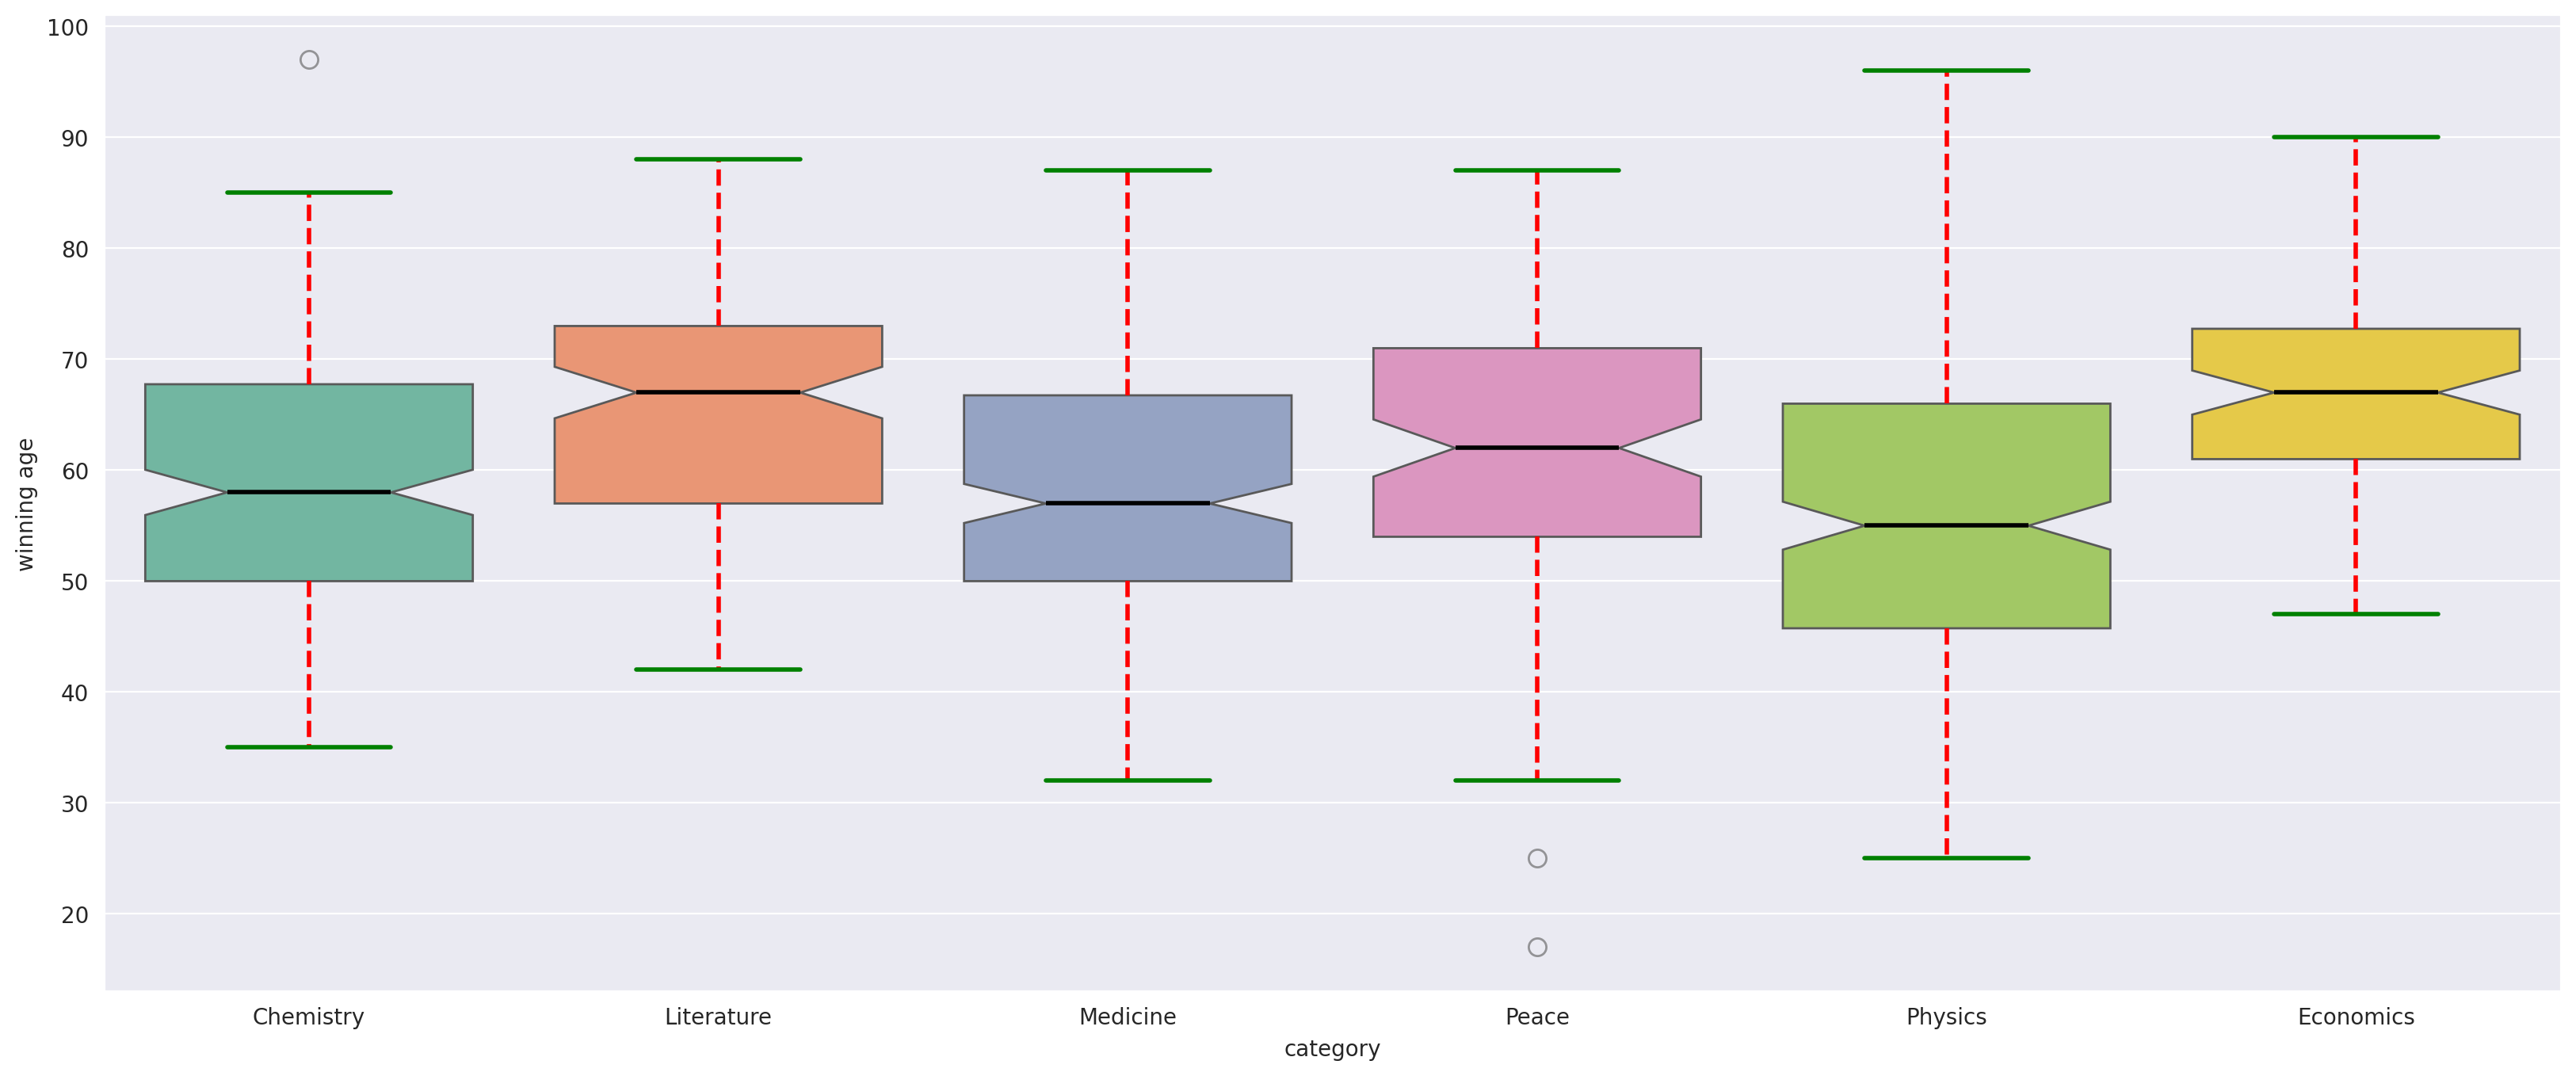

In [131]:
plt.figure(figsize=(20,8),dpi=200)
with sns.axes_style('darkgrid'):
  sns.boxplot(df_data,
              x='category',
              y='winning age',
              hue = 'category',
              notch=True, palette="Set2",
              whiskerprops=dict(color='red', linewidth=2, linestyle='--'),
              capprops=dict(color='green', linewidth=2),
              medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=8, color='purple', alpha=0.6))

plt.show()

#### Chemistry, Medicine, and Physics have similar age ranges for winners, mostly between 50 and 70 years. Winners in Literature, Peace, and Economics tend to be slightly older.

* What are the winning age trends in each category?
* Which category has the age trending up and which category has the age trending down?



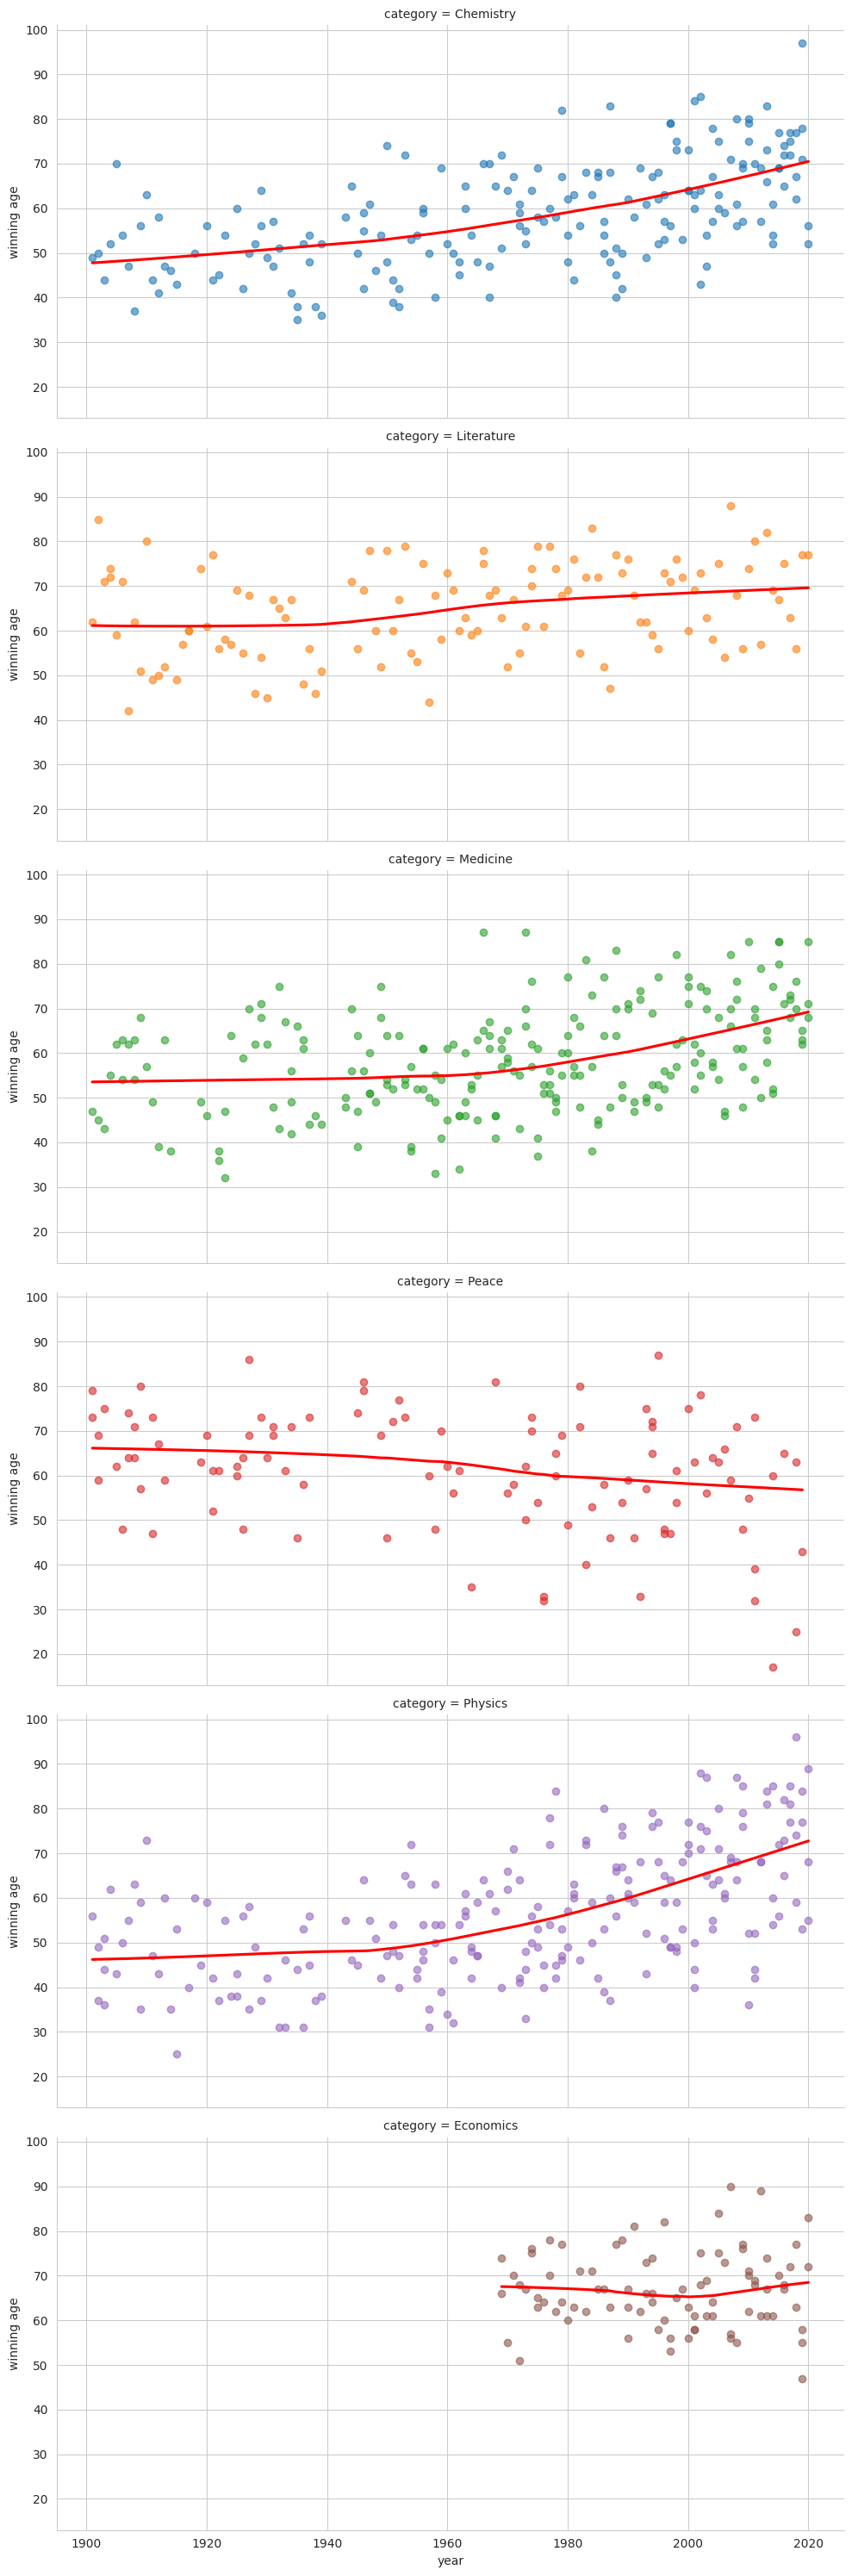

In [132]:
with sns.axes_style('whitegrid'):
    sns.lmplot(data=df_data,
               x='year',
               y='winning age',
               row = 'category',
               lowess=True,
               hue = 'category',
               aspect=2,
               scatter_kws = {'alpha': 0.6},
               line_kws = {'color': 'red'},)

plt.show()

#### Chemistry, Literature, Medicine, and Physics show an upward trend in winner ages, meaning the recipients are slightly older over the years. For Peace, the age trend is decreasing, while for Economics it has remained roughly the same.